<h1 style="text-align:center; font-size:40px;">
<b>Predicting CO₂ Emissions from Cattle-Driven Deforestation in the Amazon Rainforest Using Machine Learning</b>
</h1>

### Carlos Daniel Ambrosio 2022171
### Suelen Rocha 2022345

# Exploratory Data Analysis (EDA)

<hr style="height:4px;border:none;background-color:black;">

In [21]:
# Importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import geopandas as gpd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV


### Extracting and filtering the dataset prodes amazon

First step we had to do was to extract one of the datasets used for this project from a geopackage database

In [3]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [4]:

data = gpd.read_file("prodes_amazonia_nb2.gpkg")


C:\Users\danie\anaconda3\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'prodes_amazonia_nb2.gpkg': 'accumulated_deforestation_2000_nf_biome' (default), 'no_forest_biome', 'residual_biome', 'yearly_deforestation_biome', 'hydrography_biome', 'accumulated_deforestation_2007_biome', 'yearly_deforestation_nf_biome', 'hydrography_nf_biome', 'residual_nf_biome', 'yearly_deforestation_smaller_than_625ha_biome'. Specify layer parameter to avoid this warning.
  result = read_func(


In [5]:
#Loading the dataset containing yearly deforestation data from the Amazon biome
data = gpd.read_file("prodes_amazonia_nb2.gpkg", layer="yearly_deforestation_nf_biome")

In [6]:
#dropped the geopetry column and imported to CSV
df = data.drop(columns="geometry")
df.to_csv("prodes_amazon_legal.csv", index=False)

Secondly, I filtered the brazil beef dataset to extract only the region that we are focusing for this project

In [8]:
livestock = pd.read_csv("brazil_beef_v2_2_1.csv")

In [9]:
livestock["biome"].unique()

array(['AMAZONIA', 'CAATINGA', 'CERRADO', 'MATA ATLANTICA', 'PAMPA',
       'PANTANAL', 'UNKNOWN'], dtype=object)

In [ ]:
#Filtering the AMAZON region biome, using .strip() to remove before and after extra space and convert text to upper case using .upper()
livestock = livestock[
    livestock["biome"].str.strip().str.upper() == "AMAZONIA"
]

In [11]:
#convert to CSV and we used index=False to avoid saving the row numbers in the CSV file
livestock.to_csv("beef_amazon.csv", index=False)

### Importing the data DATASETS

### Data Understanding

For this section, we checked the dataset structure to have a better understanding of the datasets:

* data types

* data description

* duplicate values

* shape (columns and rows)

* missing values
  
* Invalid entries

In [22]:
deforestation_df = pd.read_csv("prodes_amazon_legal.csv")
beef_df = pd.read_csv("beef_amazon.csv")
co2_df = pd.read_excel("inpe_EM_BRAmz_results.xlsx", sheet_name = "Com degradação", skiprows=10)

In [3]:
deforestation_df.head()

,state,path_row,main_class,class_name,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid
0,MT,22871,desmatamento,d2023,0.0,259,2023-09-16,2023,0.030756,10329.0,Amazonia - Nao Floresta,Sentinel-2,MSI,bd04328e-979a-4706-94e9-7b5a7ec2b15b
1,AP,22560,desmatamento,d2002,NaN,232,2002-08-20,2002,5.214920,NaN,Amazônia,LANDSAT8,OLI,68272938-3419-462c-b112-101c1ba38c6b
2,MT,22871,desmatamento,d2008,NaN,230,2008-08-17,2008,0.111416,NaN,Amazônia,LANDSAT8,OLI,84d395b0-999a-4319-854e-37f6370a7bae
3,MT,21016,desmatamento,d2024,0.0,256,2024-09-12,2024,0.013637,10610.0,Amazonia - Nao Floresta,Sentinel-2,MSI,cfc86599-70eb-4486-bea5-3186786b5039
4,AM,22962,desmatamento,d2004,NaN,290,2004-10-16,2004,0.144495,NaN,Amazônia,LANDSAT8,OLI,809bafdc-4dfd-45f7-8cd8-7490795d3391


In [8]:
beef_df.head()

,year,country_of_production,biome,state_of_production,state_of_production_trase_id,municipality_of_production,municipality_of_production_trase_id,logistics_hub,product_type,port_of_export,...,country_of_destination,economic_bloc,country_of_production_trase_id,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,BRAZIL,AMAZONIA,ACRE,BR-12,BUJARI,BR-1200138,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.689217,2763.220500
1,2011,BRAZIL,AMAZONIA,ACRE,BR-12,RIO BRANCO,BR-1200401,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.975922,3912.684851
2,2011,BRAZIL,AMAZONIA,ACRE,BR-12,SENADOR GUIOMARD,BR-1200450,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.697649,2797.025472
3,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,BOCA DO ACRE,BR-1300706,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,11.786114,39216.614533
4,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,LABREA,BR-1302405,JARU,BEEF BONELESS,ITAJAA,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,NaN,NaN,NaN,NaN,1.119702,3395.156400


In [11]:
co2_df.head()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,-,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,-.1,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,-.2,NET_1st_Order,NET_2nd_Order
0,1960,842754,842754,0,-,411,133,0,0,-,0,0,-,411,133
1,1961,1685508,842754,0,-,411,222,0,0,-,0,0,-,411,222
2,1962,2528262,842754,0,-,411,276,0,0,-,0,0,-,411,276
3,1963,3371016,842754,0,-,411,311,0,-2,-,0,0,-,409,309
4,1964,4213770,842754,0,-,411,334,0,-4,-,0,0,-,407,329


In [13]:
deforestation_df["year"].unique()

array([2023, 2002, 2008, 2024, 2004, 2018, 2020, 2021, 2006, 2016, 2019,
       2014, 2022, 2013, 2010], dtype=int64)

In [15]:
beef_df["year"].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022,
       2023], dtype=int64)

In [17]:
co2_df["Year"].unique()

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020], dtype=int64)

In [19]:
deforestation_df.dtypes

state          object
path_row        int64
main_class     object
class_name     object
def_cloud     float64
julian_day      int64
image_date     object
year            int64
area_km       float64
scene_id      float64
source         object
satellite      object
sensor         object
uuid           object
dtype: object

In [21]:
beef_df.dtypes

year                                                                int64
country_of_production                                              object
biome                                                              object
state_of_production                                                object
state_of_production_trase_id                                       object
municipality_of_production                                         object
municipality_of_production_trase_id                                object
logistics_hub                                                      object
product_type                                                       object
port_of_export                                                     object
exporter                                                           object
exporter_group                                                     object
zero_deforestation_brazil_beef                                     object
forest_500_beef                       

In [23]:
co2_df.dtypes

Year                     int64
D_AreaAcc                int64
D_Area                   int64
DEGRAD_Area              int64
-                       object
VR_CO2_1stOrder          int64
VR_CO2_2ndOrder          int64
SV_CO2Emission           int64
SV_CO2Absorption         int64
-.1                     object
DEGRAD_CO2Emission       int64
DEGRAD_CO2Absorption     int64
-.2                     object
NET_1st_Order            int64
NET_2nd_Order            int64
dtype: object

In [25]:
deforestation_df.shape

(117177, 14)

In [27]:
beef_df.shape

(839727, 26)

In [29]:
co2_df.shape

(61, 15)

In [31]:
deforestation_df.duplicated().sum()

0

In [33]:
beef_df.duplicated().sum()

0

In [34]:
co2_df.duplicated().sum()

0

In [35]:
deforestation_df.isnull().sum()

state              0
path_row           0
main_class         0
class_name         0
def_cloud     107965
julian_day         0
image_date         0
year               0
area_km            0
scene_id      107988
source             0
satellite          0
sensor             0
uuid               0
dtype: int64

In [36]:
beef_df.isnull().sum()

year                                                                   0
country_of_production                                                  0
biome                                                                  0
state_of_production                                                    0
state_of_production_trase_id                                           0
municipality_of_production                                             0
municipality_of_production_trase_id                                    0
logistics_hub                                                          0
product_type                                                           0
port_of_export                                                         0
exporter                                                               0
exporter_group                                                         0
zero_deforestation_brazil_beef                                         0
forest_500_beef                                    

In [41]:
co2_df.isnull().sum()

Year                    0
D_AreaAcc               0
D_Area                  0
DEGRAD_Area             0
-                       0
VR_CO2_1stOrder         0
VR_CO2_2ndOrder         0
SV_CO2Emission          0
SV_CO2Absorption        0
-.1                     0
DEGRAD_CO2Emission      0
DEGRAD_CO2Absorption    0
-.2                     0
NET_1st_Order           0
NET_2nd_Order           0
dtype: int64

In [43]:
deforestation_df.describe()

,path_row,def_cloud,julian_day,year,area_km,scene_id
count,117177.000000,9212.0,117177.000000,117177.000000,117177.000000,9189.000000
mean,22604.030245,0.0,244.723461,2011.732507,0.148804,10451.843073
std,2173.674931,0.0,41.729522,7.432707,0.622272,154.620532
min,158.000000,0.0,15.000000,2002.000000,0.000020,10242.000000
25%,22567.000000,0.0,224.000000,2004.000000,0.019603,10319.000000
50%,22871.000000,0.0,240.000000,2010.000000,0.038777,10424.000000
75%,23068.000000,0.0,270.000000,2019.000000,0.094432,10523.000000
max,33008.000000,0.0,361.000000,2024.000000,53.043873,10775.000000


In [45]:
beef_df.describe()

,year,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
count,839727.000000,630603.000000,6.306030e+05,6.306030e+05,808268.000000,839727.000000,8.397270e+05
mean,2017.910960,3.152878,1.431608e+03,1.319155e+03,114.752244,7.560965,2.547733e+04
std,3.810633,32.922416,1.658885e+04,1.541352e+04,548.265643,34.026620,1.205131e+05
min,2011.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.299620,1.483560e+02
25%,2015.000000,0.118720,4.290230e+01,3.834555e+01,13.955774,1.014637,3.241834e+03
50%,2019.000000,0.440201,1.697448e+02,1.537368e+02,28.407606,1.938585,6.313568e+03
75%,2021.000000,1.526267,6.197420e+02,5.642000e+02,73.893583,4.911512,1.625017e+04
max,2023.000000,8432.792534,4.252106e+06,3.972162e+06,100000.437286,4278.000019,1.586512e+07


In [362]:
co2_df.describe()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,NET_1st_Order,NET_2nd_Order
count,61.000000,6.100000e+01,6.100000e+01,6.100000e+01,61.000000,61.000000,61.000000,61.000000,61.00000,61.000000,61.000000,61.000000
mean,1990.000000,3.746415e+07,1.324505e+06,4.035045e+05,653.622951,616.196721,48.704918,-86.032787,81.52459,-54.590164,643.163934,605.688525
std,17.752934,2.365221e+07,6.324252e+05,7.129856e+05,302.902634,260.263701,45.004201,61.896410,146.53755,84.977718,308.937004,270.875097
min,1960.000000,8.427540e+05,4.571000e+05,0.000000e+00,234.000000,133.000000,0.000000,-185.000000,0.00000,-245.000000,108.000000,133.000000
25%,1975.000000,1.348406e+07,8.427540e+05,0.000000e+00,411.000000,381.000000,7.000000,-143.000000,0.00000,-31.000000,396.000000,366.000000
50%,1990.000000,4.030233e+07,1.103000e+06,1.558720e+05,541.000000,603.000000,39.000000,-81.000000,34.00000,-18.000000,550.000000,667.000000
75%,2005.000000,6.107624e+07,1.822600e+06,1.558720e+05,888.000000,844.000000,83.000000,-28.000000,34.00000,0.000000,880.000000,853.000000
max,2020.000000,6.972315e+07,2.905900e+06,2.741165e+06,1416.000000,1107.000000,138.000000,0.000000,691.00000,0.000000,1380.000000,1053.000000


### Invalid Entries

Count how many rows in the importer column contain quotation marks and special characters from the importer column

In [50]:

beef_df["importer"].astype(str).str.contains('"', na=False).sum()

1450

In [52]:

beef_df["importer"].str.contains('&#', na=False).sum()

193

# Data Distribution


### deforestation_df
The histograms show that most variables are not normally distributed. path_row and scene_id are concentrated around specific values, julian_day is more spread across the dataset, year is distributed across multiple years, and area_km is highly right-skewed with most values close to zero.

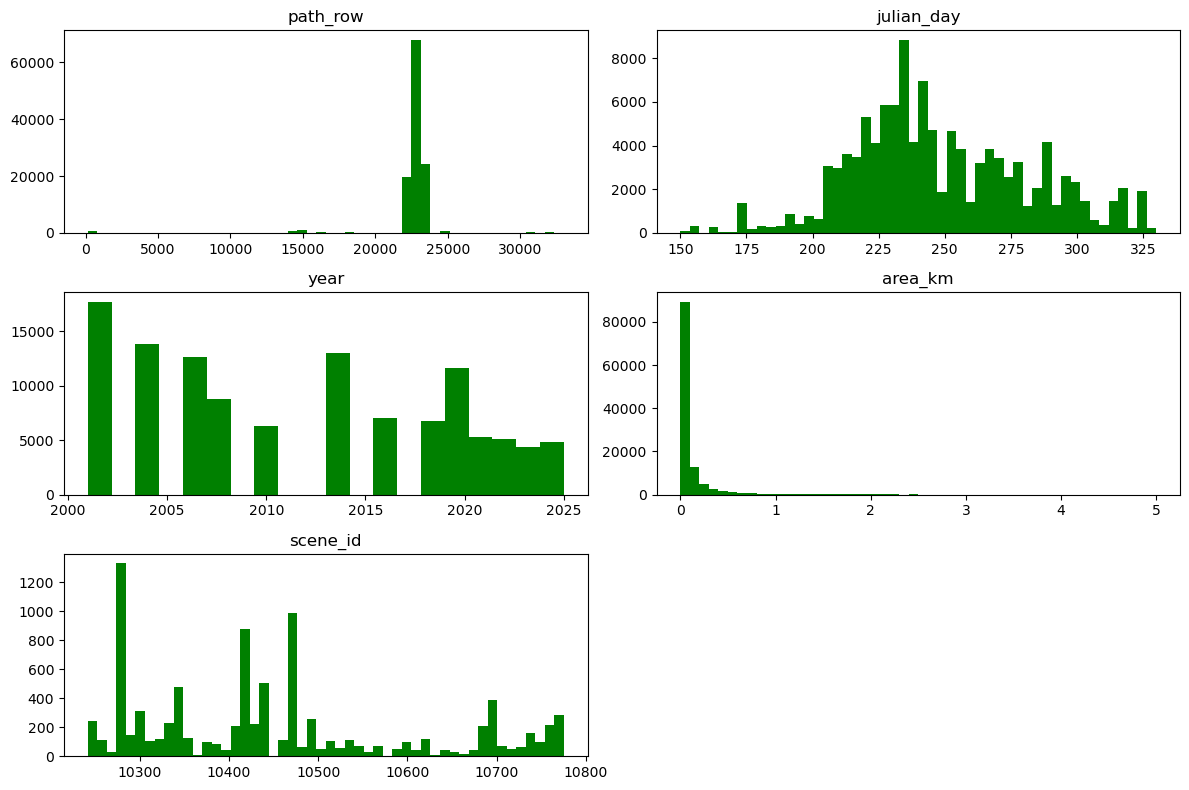

In [68]:
plt.figure(figsize=(12, 8))


plt.subplot(3, 2, 1)
plt.hist(deforestation_df["path_row"], bins=50, color="green")
plt.title("path_row")


plt.subplot(3, 2, 2)
plt.hist(deforestation_df["julian_day"], bins=50, range=(150, 330), color="green")
plt.title("julian_day")


plt.subplot(3, 2, 3)
plt.hist(deforestation_df["year"], bins=20, range=(2001, 2025), color="green")
plt.title("year")


plt.subplot(3, 2, 4)
plt.hist(deforestation_df["area_km"], bins=50, range=(0, 5), color="green")
plt.title("area_km")


plt.subplot(3, 2, 5)
plt.hist(deforestation_df["scene_id"], bins=50, color="green")
plt.title("scene_id")

plt.tight_layout()
plt.show()

### beef_df

The histograms below show different distributions across the variables. year is spread across multiple years, while cattle_deforestation, co2 gross, and co2 net and fob are right-skewed, with most values grouped near zero and fewer higher values. land_use has a more spread-out distribution, but with right skewness, volume has most observations between 0.5 and 1.

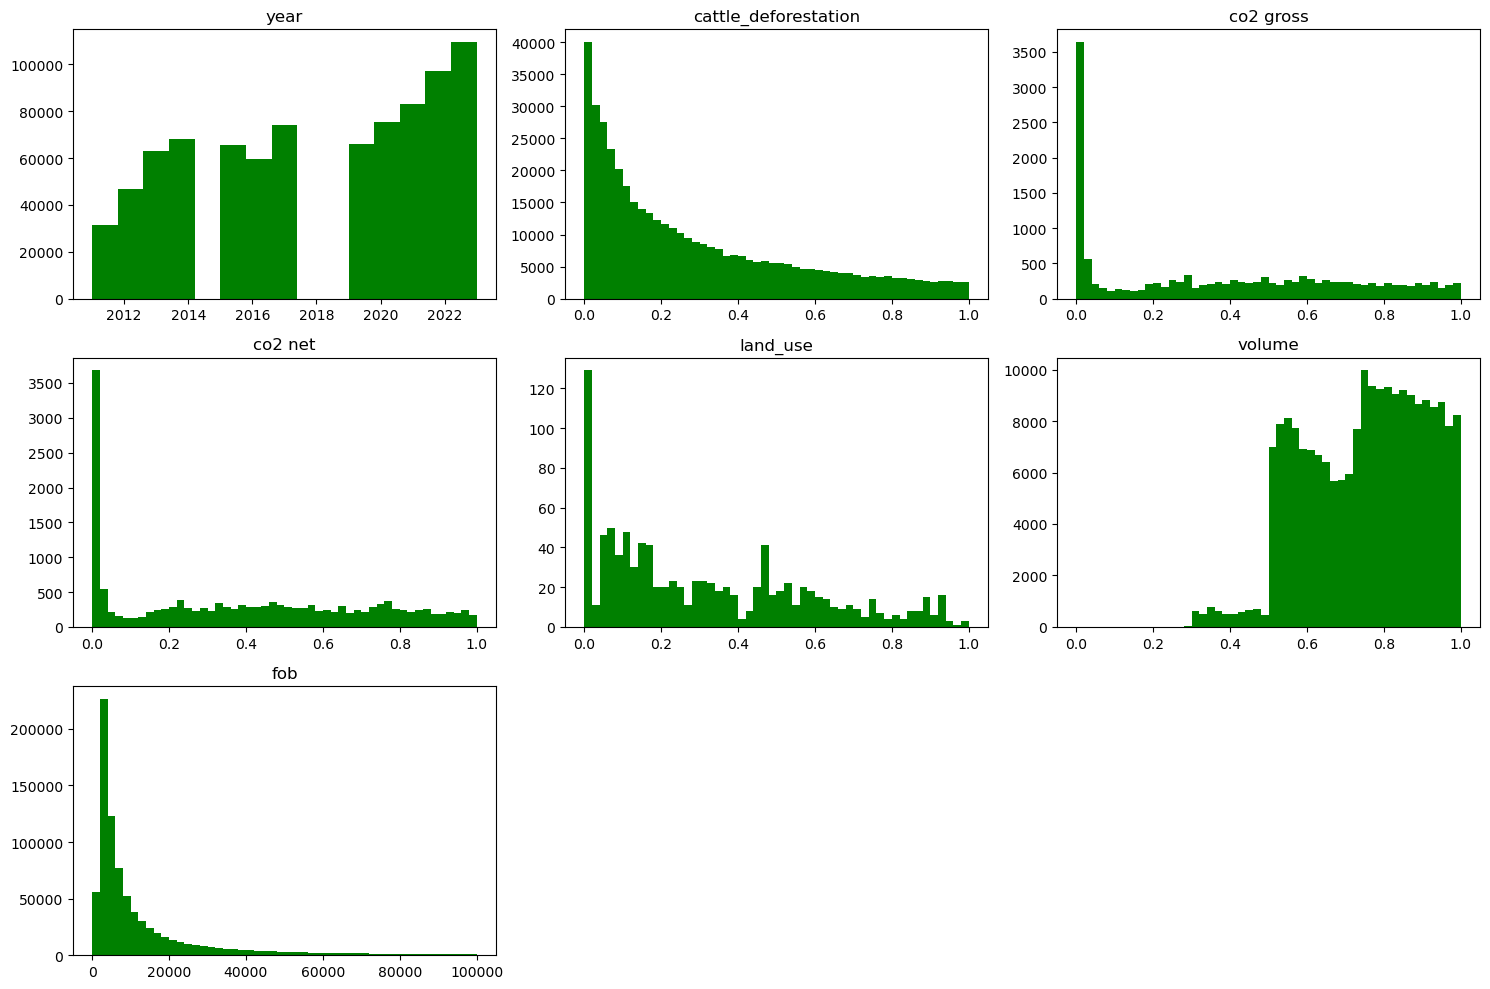

In [76]:


plt.figure(figsize=(15, 10))


plt.subplot(3, 3, 1)
plt.hist(beef_df["year"], bins=15, range=(2011, 2023), color = "green")
plt.title("year")


plt.subplot(3, 3, 2)
plt.hist(beef_df["cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color ="green")
plt.title("cattle_deforestation")


plt.subplot(3, 3, 3)
plt.hist(beef_df["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color = "green")
plt.title("co2 gross")


plt.subplot(3, 3, 4)
plt.hist(beef_df["co2_net_emissions_cattle_deforestation_5_year_total_exposure"], bins=50, range=(0, 1), color = "green")
plt.title("co2 net")


plt.subplot(3, 3, 5)
plt.hist(beef_df["land_use"], bins=50, range=(0, 1), color ="green")
plt.title("land_use")


plt.subplot(3, 3, 6)
plt.hist(beef_df["volume"], bins=50, range=(0, 1), color = "green")
plt.title("volume")


plt.subplot(3, 3, 7)
plt.hist(beef_df["fob"], bins=50, range=(0, 100000),color = "green")
plt.title("fob")

plt.tight_layout()
plt.show()

### co2_df
The histograms show different distributions across the variables. Some variables, such as DEGRAD Area, SV CO2Emission, and DEGRAD CO2Emission, are highly right-skewed with most values close to zero, while variables like VR CO2 1stOrder, VR CO2 2ndOrder, NET 1st Order, and NET 2nd Order are more spread across the dataset.

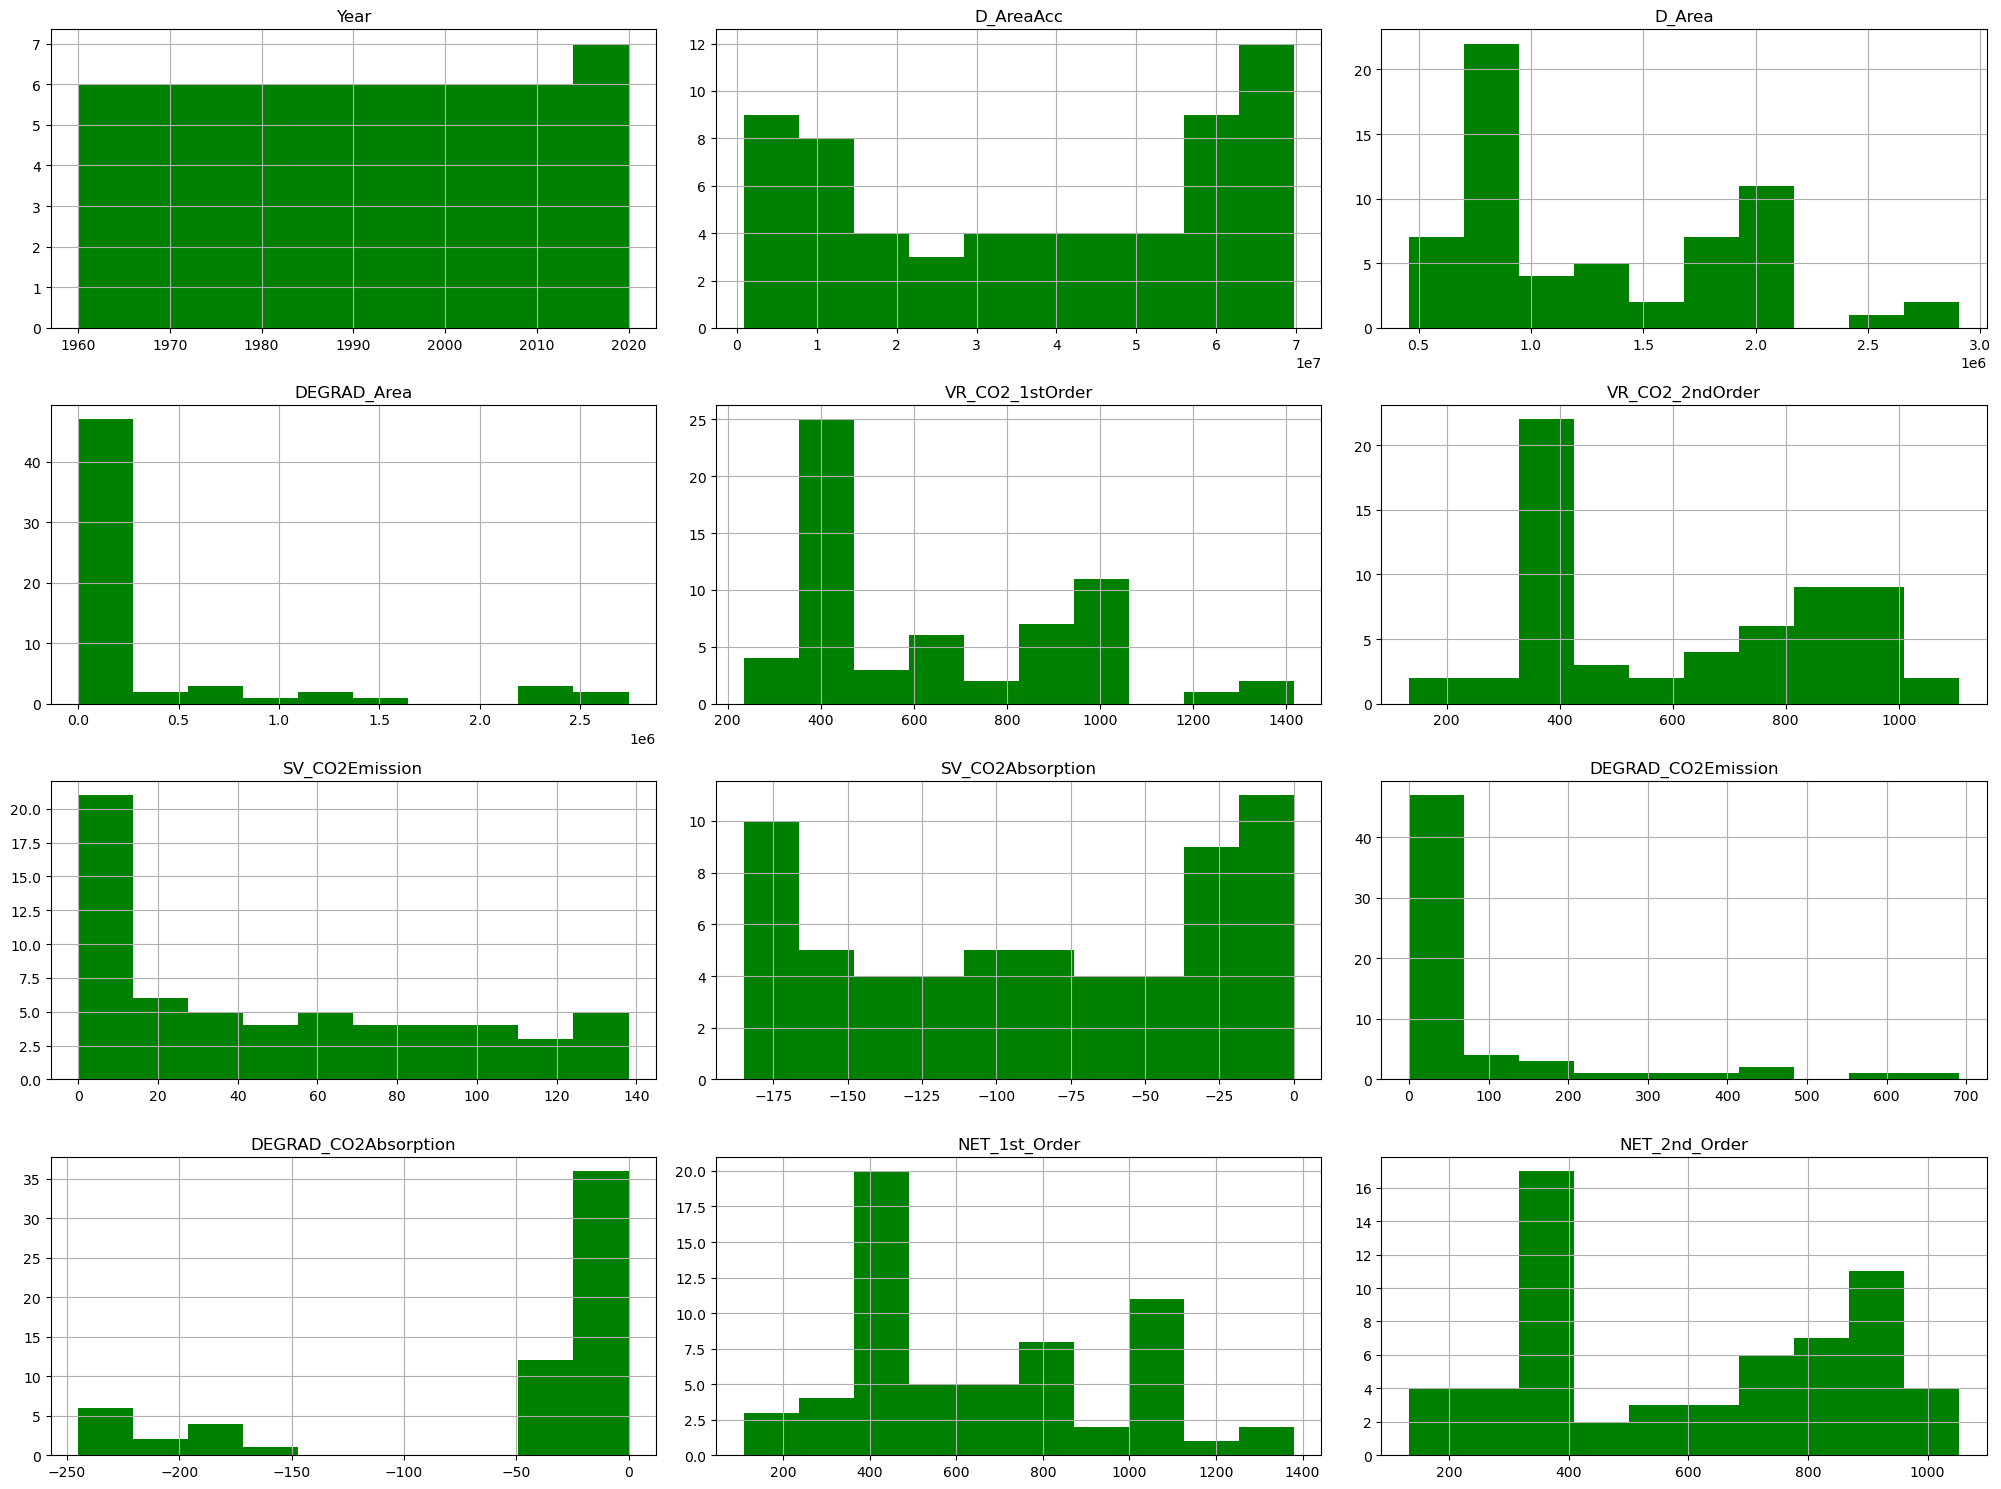

In [80]:
co2_df.hist(figsize=(20,15), color ="green")
plt.tight_layout()
plt.show()

## Checking outliers

Boxplots were used to understand the distribution of the variables and identify extreme values across the datasets.

* Boxplot 1 shows that most deforestation values are very close to 0 km², with a few outliers reaching up to around 50 km², indicating a highly skewed distribution.

* Boxplot 2 shows similar skewness across the beef-related variables, where most observations are concentrated near lower values while a few extreme outliers are present. Variables such as FOB, CO2 Gross, and CO2 Net contain very large values compared to the majority of the dataset, indicating high variability and presence of outliers.

* Boxplot 3 NET_2nd_Order shows a more balanced distribution, with values roughly between 130 and 1000 and a median around 650, making it easier to interpret typical values.

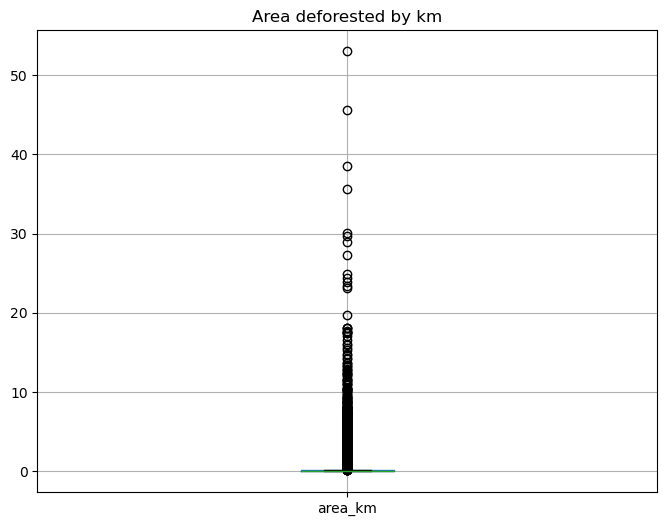

In [51]:
plt.figure(figsize=(8,6))
deforestation_df.boxplot(column=['area_km'])
plt.title('Area deforested by km')
plt.show()

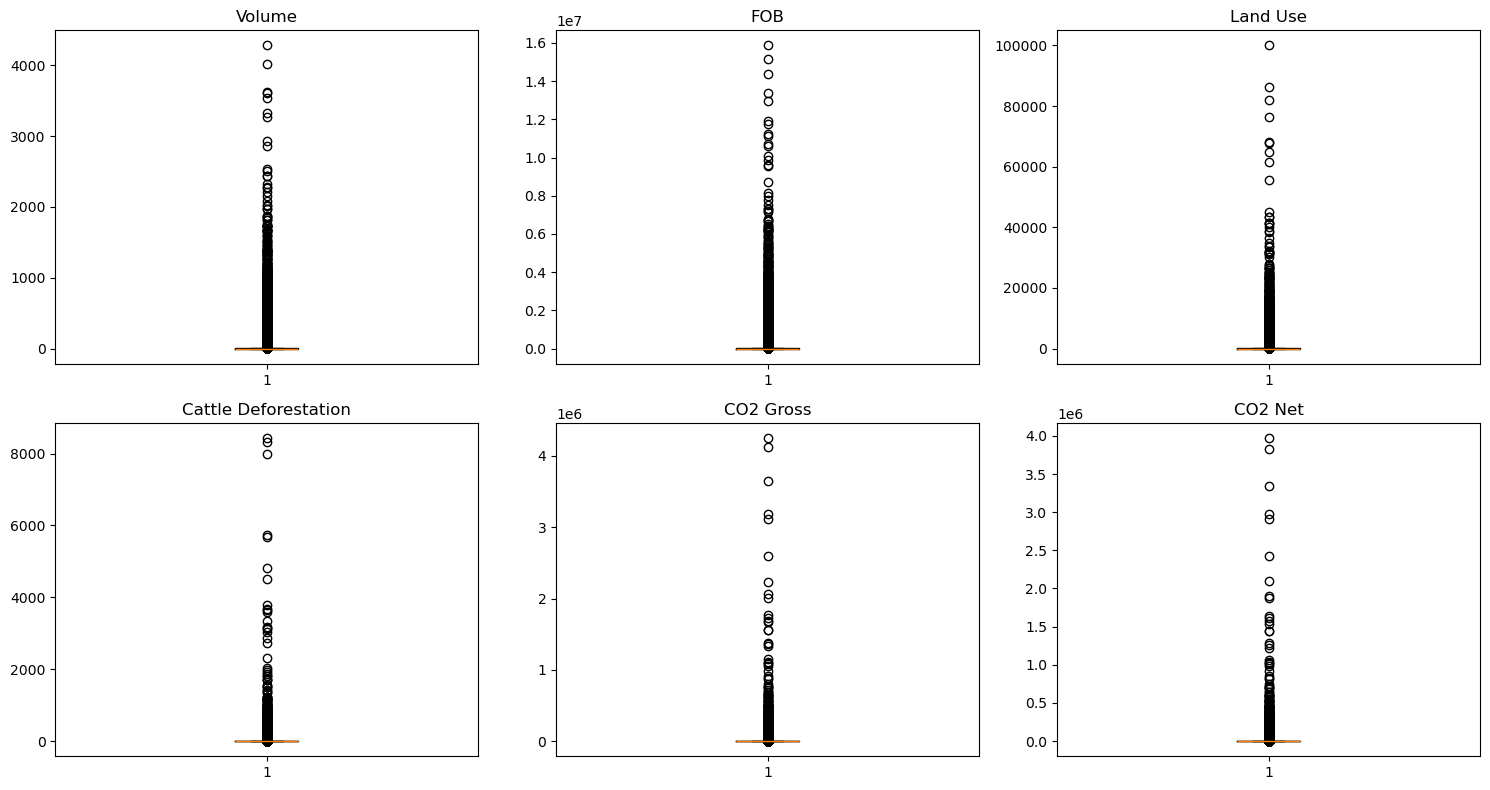

In [368]:

plt.figure(figsize=(15,8))


plt.subplot(2, 3, 1)
plt.boxplot(beef_df["volume"].dropna())
plt.title("Volume")

plt.subplot(2, 3, 2)
plt.boxplot(beef_df["fob"].dropna())
plt.title("FOB")


plt.subplot(2, 3, 3)
plt.boxplot(beef_df["land_use"].dropna())
plt.title("Land Use")


plt.subplot(2, 3, 4)
plt.boxplot(beef_df["cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("Cattle Deforestation")


plt.subplot(2, 3, 5)
plt.boxplot(beef_df["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("CO2 Gross")


plt.subplot(2, 3, 6)
plt.boxplot(beef_df["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].dropna())
plt.title("CO2 Net")

plt.tight_layout()
plt.show()

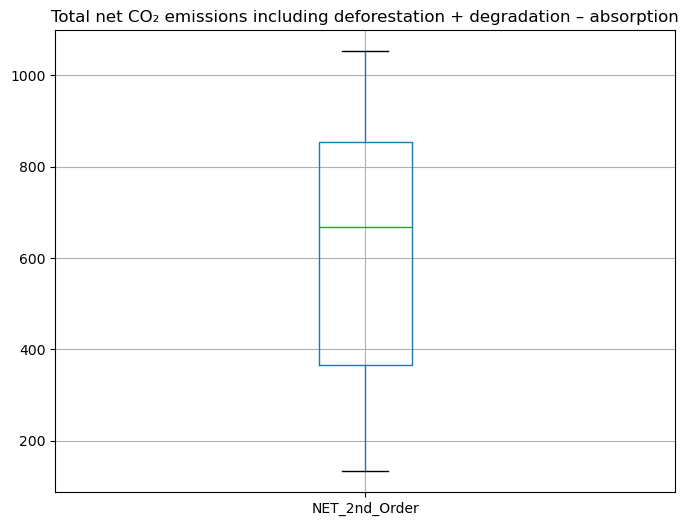

In [46]:
plt.figure(figsize=(8,6))
co2_df.boxplot(column=['NET_2nd_Order'])
plt.title('Total net CO₂ emissions including deforestation + degradation – absorption')
plt.show()

## CHECKING FEATURES RELATIONSHIP
These scatter plots were use to explore how variables behave over time and how they relate to each other. In the first plot year vs area, most values stay below 20 km², with only one clear outlier reaching just above 45 km² around the early 2000s, while more recent years show lower and more stable values. station and CO₂, with values up to around 100,000, and deforestation reaching roughly 8,000.

In [9]:
# fig_2d=px.scatter(deforestation_df,
#            x='year',
#            y='area_km',
#            color='year',
#            size='year',
#            hover_data=['area_km'])
# fig_2d.show()

In the scatter matrix, there is a strong  linear relationship between Volume and FOB, reaching up to about 4,000 (volume) and 15M (fob). Land use also shows a positive relationship with defore.CO₂ gross and net emissions are highly correlated, both exceeding 4 million

In [11]:
# fig_matrix = px.scatter_matrix(
#     beef_df,
#     dimensions=[
#         'volume',
#         'fob',
#         'cattle_deforestation_5_year_total_exposure',
#         'land_use',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure'
#     ],
#     labels={
#         'cattle_deforestation_5_year_total_exposure': 'Deforestation_5year',
#         'volume': 'Volume',
#         'fob': 'FOB',
#         'land_use': 'land',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure': 'co2_gross',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure': 'co2_net'
#     },
#     color='year'
# )

# fig_matrix.update_layout( width=1070, height=1070)
# fig_matrix.show()

In the final plot, NET CO₂ emissions increase from around 200 in the 1960s to peaks of about 1,100 in the early 2000s, then decline and fluctuate in recent years between 200 and 80

In [13]:
# fig_2d=px.scatter(co2_df,
#            x='Year',
#            y='NET_2nd_Order',
#            color='Year',
#            size='Year',
#            hover_data=['NET_2nd_Order'])
# fig_2d.show()

## Simple aggregations

Simple aggregations were used to track how values change over time. Deforestation was highest early on around 3100 km² in 2002 and decreased later. In contrast, beef volume increased from about 223k in 2011 to 690k in 2023, and FOB reached over 2.7 billion, showing economic growth. CO₂ net emissions also rose significantly, reaching over 120 million.

In [54]:
deforestation_df.groupby("year")["area_km"].sum()

year
2002    3103.592468
2004    2760.037609
2006    1882.480304
2008    1163.067041
2010     756.332634
2013    1054.657118
2014     642.272501
2016    1029.121123
2018    1112.089110
2019     679.653633
2020     668.548375
2021     719.338490
2022     726.329228
2023     584.821165
2024     554.039276
Name: area_km, dtype: float64

In [55]:
beef_df.groupby("year")["volume"].sum()

year
2011    223371.898449
2012    428169.688837
2013    609881.468995
2014    599552.803322
2015    483791.314941
2016    462177.754768
2017    582599.476231
2019    505467.315764
2020    624532.444719
2021    502095.163737
2022    636842.113125
2023    690665.151333
Name: volume, dtype: float64

In [56]:
beef_df.groupby("year")["fob"].sum()

year
2011    7.301116e+08
2012    1.414814e+09
2013    1.934537e+09
2014    1.964155e+09
2015    1.387633e+09
2016    1.206347e+09
2017    1.598278e+09
2019    1.648547e+09
2020    2.137257e+09
2021    1.931284e+09
2022    2.696068e+09
2023    2.744971e+09
Name: fob, dtype: float64

In [57]:
beef_df.groupby("year")["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].sum()

year
2011    0.000000e+00
2012    0.000000e+00
2013    0.000000e+00
2014    0.000000e+00
2015    9.314900e+07
2016    8.958171e+07
2017    9.943585e+07
2019    9.643755e+07
2020    1.170607e+08
2021    9.392564e+07
2022    1.156021e+08
2023    1.266708e+08
Name: co2_net_emissions_cattle_deforestation_5_year_total_exposure, dtype: float64

### EDA Conclusions
After conducting an exploratory data analysis (EDA) on the three datasets, it was determined that integrating all of them would not be appropriate for the scope of this project. The primary objective is to predict CO₂ emissions specifically associated with beef production.

The beef dataset alone contains all the relevant features required to support this objective, including variables directly linked to cattle-related deforestation and emissions. Although we initially considered incorporating the area_km variable from the deforestation dataset and the CO₂ column from the emissions dataset, further analysis revealed a critical limitation.

Deforestation and CO₂ datasets represent aggregate values, containing multiple sources beyond beef production. As a result, including these variables would introduce noise and reduce the focus of the model, as they do not isolate deforestation or emissions caused only by cattle-related activities.

Therefore, to maintain the  relevance of the predictive model, the decision was made to rely exclusively on the beef dataset, which provides targeted and domain-specific information aligned with the research objective

# Data Preparation

<hr style="height:4px;border:none;background-color:black;">

## Missing values approach

For the data preparation stage. We used three different techniques, and in each of them we did 4 different models. 

* The first one is through a model-based imputation, where we used machine learning to predict the missing values present in the dataset.
* The second technique, we dropped all the missing values using drop.na before the modelling.
* The third technique we used median imputation to fill in the missing values.


### Removing Invalid entries

In this section, after analysing the data during the EDA phase, special characters were identified and removed using the .replace() function.

In [5]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('&#', '')

In [6]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('"', '')

In [8]:
beef_df["importer"].astype(str).str.contains('"', na=False).sum()

0

In [10]:
beef_df["importer"].str.contains('&#', na=False).sum()

0

### Creating a copy of the dataset for each technique

In [12]:
beef_df_imputation = beef_df.copy()

In [13]:
beef_df_missing_values=beef_df.copy()

In [15]:
beef_df_median_Input= beef_df.copy()

### Dropping missing values for "missing values" approach

In [17]:
beef_df_missing_values = beef_df.dropna(subset=["land_use", "cattle_deforestation_5_year_total_exposure", "co2_gross_emissions_cattle_deforestation_5_year_total_exposure", "co2_net_emissions_cattle_deforestation_5_year_total_exposure" ])

### Dropping unecessary columns
We decided to remove the columns below because they do not provide meaningful information for the analysis. Some columns only contain IDs, the "country_of_production" contains only Brazil, and the biome column contains only AMAZONIA. In addition, the "import_group" column was removed because the "importer" column already provides the same information.

In [20]:
removing_columns = [
    "country_of_production",
    "biome",
    "country_of_production_trase_id",
    "state_of_production_trase_id",
    "municipality_of_production_trase_id",
    "importer_group"
]

beef_df_imputation = beef_df_imputation.drop(columns=removing_columns)
beef_df_median_Input = beef_df_median_Input.drop(columns=removing_columns)
beef_df_missing_values = beef_df_missing_values.drop(columns=removing_columns)

## Label encoding
We decided to use label encoding because the dataset is very large and contains a high number of categories and observations. Using other encoding methods would increase the complexity and require more computational resources, making them less feasible for this project.

In [22]:
# beef_df_imputation
for col in beef_df_imputation.select_dtypes(include="object").columns:
    le = LabelEncoder()
    beef_df_imputation[col] = le.fit_transform(beef_df_imputation[col].astype(str))


# beef_df_median_Input
for col in beef_df_median_Input.select_dtypes(include="object").columns:
    le = LabelEncoder()
    beef_df_median_Input[col] = le.fit_transform(beef_df_median_Input[col].astype(str))


# beef_df_missing_values
for col in beef_df_missing_values.select_dtypes(include="object").columns:
    le = LabelEncoder()
    beef_df_missing_values[col] = le.fit_transform(beef_df_missing_values[col].astype(str))

In [23]:
beef_df_missing_values

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
209124,2015,1,155,43,1,13,82,82,6,6,3802,87,75,93,4.217339,2384.074765,2220.032331,46.238954,2.005120,4497.830700
209125,2015,1,155,43,1,13,82,82,6,6,4807,32,30,31,2.166561,1224.763490,1140.490469,23.754198,1.030084,2370.341400
209126,2015,1,155,72,0,23,85,85,5,5,5370,2,2,4,3.755715,2123.117248,1977.030671,41.177703,1.785643,4840.432800
209127,2015,1,155,72,1,13,85,85,5,5,5675,118,103,115,5.327990,3011.929153,2804.685573,58.416144,2.533176,6097.198800
209128,2015,1,155,72,1,17,85,85,5,5,2945,22,21,46,5.448765,3080.204024,2868.262615,59.740330,2.590598,8358.991200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,334,98,3,17,85,85,1,1,4957,26,25,17,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,334,98,3,23,104,102,4,2,2661,87,75,93,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,334,98,3,23,104,102,4,2,3805,87,75,93,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,334,98,3,23,104,102,4,2,5303,58,52,65,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


In [25]:
beef_df_median_Input

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,NaN,NaN,NaN,NaN,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,NaN,NaN,NaN,NaN,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


In [26]:
beef_df_imputation

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,NaN,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,NaN,NaN,NaN,NaN,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,NaN,NaN,NaN,NaN,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


In [27]:
beef_df_imputation.dtypes

year                                                                int64
state_of_production                                                 int32
municipality_of_production                                          int32
logistics_hub                                                       int32
product_type                                                        int32
port_of_export                                                      int32
exporter                                                            int32
exporter_group                                                      int32
zero_deforestation_brazil_beef                                      int32
forest_500_beef                                                     int32
importer                                                            int32
country_of_destination                                              int32
economic_bloc                                                       int32
country_of_destination_trase_id       

# Model Based imputation for Missing Values

This technique is used to predict the missing values using specific columns in the data.

### Land use Imputation 

To predict the "land_use" we used "fob" and "volume" as predictors

In [32]:
# Keep only the rows where the land_use column has values (not missing)
known_land_use = beef_df_imputation[beef_df_imputation["land_use"].notna()]

# Keep only the rows where the land_use column has missing values
missing_land_use = beef_df_imputation[beef_df_imputation["land_use"].isna()]

In [34]:
# Select FOB and volume as input features
X = known_land_use[["fob", "volume"]]

# Select land_use as the target variable
y = known_land_use["land_use"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [35]:
#Training the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [37]:
# Prediction
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


# Predict missing land_use values using fob and volume
predicted_land_use = model.predict(missing_land_use[["fob", "volume"]])

In [38]:
# Display MAE and R2 scores for the training and testing sets
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 40.6307022897135
R2: 0.7560642722597537
Test evaluation
MAE: 41.11795243644716
R2: 0.7539673144566335


In [40]:
# Replace missing land_use values with the predicted values
beef_df_imputation.loc[beef_df_imputation["land_use"].isna(),"land_use"] = predicted_land_use

In [41]:
beef_df_imputation.head()

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,20.745896,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,24.766967,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,NaN,NaN,NaN,20.864153,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,NaN,NaN,NaN,171.631517,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,NaN,NaN,NaN,26.136973,1.119702,3395.156400


### cattle_deforestation_5_year_total_exposure inputation

To predict cattle_deforestation, we used volume, fob, and land_use as input features. Random Forest was chosen because it can capture non-linear relationships between the variables.

In [43]:
known_deforestation = beef_df_imputation[beef_df_imputation["cattle_deforestation_5_year_total_exposure"].notna()]
missing_deforestation = beef_df_imputation[beef_df_imputation["cattle_deforestation_5_year_total_exposure"].isna()]

In [44]:
X = known_deforestation[["volume", "fob", "land_use"]]
y = known_deforestation["cattle_deforestation_5_year_total_exposure"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [45]:
# We carried out a Random forest grid search to check for the best parameters

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

In [46]:
#Training the model using the hyperparameters provided by the grid search
rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=3, n_estimators=120, random_state=42)

In [47]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)


predicted_deforestation = rf_model.predict(missing_deforestation[["volume", "fob", "land_use"]])

In [48]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 2.674444905780075
R2: 0.7790824379905072
Test evaluation
MAE: 2.668498691158063
R2: 0.6134918100243524


In [49]:
beef_df_imputation.loc[beef_df_imputation["cattle_deforestation_5_year_total_exposure"].isna(),"cattle_deforestation_5_year_total_exposure"] = predicted_deforestation

In [50]:
beef_df_imputation

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,0.527351,NaN,NaN,20.745896,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,0.718051,NaN,NaN,24.766967,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,0.527351,NaN,NaN,20.864153,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,4.737146,NaN,NaN,171.631517,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,0.707553,NaN,NaN,26.136973,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


## Gross CO2 emissions inputation

In [52]:
known_co2_gross = beef_df_imputation[beef_df_imputation["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"].notna()]
missing_co2_gross = beef_df_imputation[beef_df_imputation["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"].isna()]

In [53]:
X = known_co2_gross[["volume", "fob", "land_use", "cattle_deforestation_5_year_total_exposure"]]
y = known_co2_gross["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [55]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


predicted_co2_gross = model.predict(missing_co2_gross[["volume", "fob", "land_use", "cattle_deforestation_5_year_total_exposure"]])

In [56]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 314.15122749781466
R2: 0.9825011797325941
Test evaluation
MAE: 301.1103830628307
R2: 0.9888295549516196


In [57]:
beef_df_imputation.loc[beef_df_imputation["co2_gross_emissions_cattle_deforestation_5_year_total_exposure"].isna(),"co2_gross_emissions_cattle_deforestation_5_year_total_exposure"] = predicted_co2_gross

In [58]:
beef_df_imputation

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,0.527351,162.612695,NaN,20.745896,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,0.718051,254.129293,NaN,24.766967,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,0.527351,162.526632,NaN,20.864153,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,4.737146,2202.698415,NaN,171.631517,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,0.707553,256.784735,NaN,26.136973,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


## Net CO2 emissions

In [60]:
known_co2_net = beef_df_imputation[beef_df_imputation["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].notna()]
missing_co2_net = beef_df_imputation[beef_df_imputation["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].isna()]

In [61]:
features = ["volume", "fob", "land_use", "cattle_deforestation_5_year_total_exposure"]

X = known_co2_net[["volume", "fob", "land_use", "cattle_deforestation_5_year_total_exposure"]]
y = known_co2_net["co2_net_emissions_cattle_deforestation_5_year_total_exposure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [63]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


predicted_co2_net = model.predict(missing_co2_net[["volume", "fob", "land_use", "cattle_deforestation_5_year_total_exposure"]])

In [64]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 312.6654183257446
R2: 0.9799087185783634
Test evaluation
MAE: 299.58001724905034
R2: 0.987340209834678


In [65]:
beef_df_imputation.loc[beef_df_imputation["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].isna(),"co2_net_emissions_cattle_deforestation_5_year_total_exposure"] = predicted_co2_net

In [66]:
beef_df_imputation

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,0.527351,162.612695,144.635970,20.745896,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,0.718051,254.129293,229.264429,24.766967,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,0.527351,162.526632,144.547774,20.864153,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,4.737146,2202.698415,2033.471650,171.631517,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,0.707553,256.784735,232.533021,26.136973,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


# Modelling

<hr style="height:4px;border:none;background-color:black;">


For the modelling stage, three different approaches were used based on how the missing values were handled in the previous stage. Each approach was tested using KNN Regressor, Linear Regression, Random Forest Regressor, and PLS Regression.

* approach 1- Model-based inputation
* Approach 2 - Dropping Missing Values
* approach 3- Median Imputation

For all approaches we divided the dataset into 80% training and 20% test

The following evaluation metrics were used for all approaches. In addition, the data was randomly shuffled and split into 5 folds for cross-validation, where the model was trained and tested on different parts of the dataset and evaluated using the R2 score. 
##### Train:
* MAE measures average prediction error.
* R2 measures how well the model fits the data.

##### Test
* MAE average error on test data
* R2 performances on unseen data

##### Cross-Validation
Cross-validation R2 scores were used to evaluate the overall model performance.

# 1st Approach: Machine Learning with Model-Based Missing Value Imputation

## 1.1- Linear Regression (Model-based Imputation)

In [86]:
# Dropped the "co2_gross" as Target variable (y) and "co2_net" due to correlation to co2_gross, Linear Regression does not handle multicollinearity well.
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure','co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Robust Scaler
Due to the presence of outliers in this dataset wee used RobustScaler because it removes the median and scales the data using the interquartile range (IQR).

In [89]:
scaler = RobustScaler()
# fit_transform learns the scaling values from the training data (X_train) and transform applies the scaling to the data (X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

### Predict
Linear Regression model predicts values by finding the best linear relationship between the input features and target variable.

In [92]:
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

### Evaluation

In [92]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 273.9131046697637
R2: 0.9867665824164484
Test Evaluation
MAE: 271.8581374777753
R2: 0.9782909645336213


In [126]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lr_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.97829096 0.98814503 0.98796608 0.98233821 0.98115905]
Mean R2: 0.9835798688184383



## 1.2 - KNN Regressor (Model-based Imputation)


In [130]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [134]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Apply PCA on the scaled training data and transform the scaled testing data using the same components
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

grid search for knn

In [171]:
knn = KNeighborsRegressor()
# Defined hyperparameters to test KNN model
param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train_pca, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.9087518957201114


In [136]:
knn = KNeighborsRegressor(n_neighbors=11, weights="distance", metric="euclidean" )

knn.fit(X_train_pca, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=11, weights='distance')

### Predict
KNN checks at the nearest neighbors of each data point and predicts a value based on those neighbors

In [138]:
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)


### Evaluation

In [139]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 0.0
R2: 1.0
Test evaluation
MAE: 83.43013544663123
R2: 0.9966405648835481


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

In [ ]:
import matplotlib.pyplot as plt

# Predicted vs Actual for KNN
plt.figure(figsize=(6,6))

# Scatter plot
plt.scatter(y_test, y_test_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regression - Predicted vs Actual")

plt.tight_layout()oo

# Save image
#plt.savefig(
  #  "knn_predicted_vs_actual.png",
   # dpi=300,
    #bbox_inches="tight"
)

plt.show()

## 1.3- Random Forest (Model-based Imputation)

In [127]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [89]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 120}
Best CV Score: 0.8785924947947744


In [129]:
rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=3, n_estimators=120, random_state=42)

### Predict
Random Forest Regression model predicts values by combining the results from 120 decision trees and averaging their predictions.

In [130]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

### Evaluation

In [140]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 248.85190771003207
R2: 0.9953535586432736

Test evaluation
MAE: 247.53139669641848
R2: 0.9911219641463066


In [133]:

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.97864882 0.97167708 0.80576506 0.98226313 0.97957491]
Mean R2: 0.943585798606539


## 1.4 - Partial Least Squares  (Model-based Imputation)

For the PLS model, it was chosen because it handles multicollinearity well between the features.

To implement the model, the following steps were performed:

* Scaled the data using RobustScaler
* Trained the PLS regression model on the scaled data

In [94]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
scaler = RobustScaler()

In [97]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pls_model = PLSRegression(n_components=3)


pls_model.fit(X_train_scaled, y_train)


PLSRegression(n_components=3)

### Predict
The PLS Regression model predicts values by finding relationships between the input features and target variable using latent components

In [99]:
y_train_pred = pls_model.predict(X_train_scaled)
y_test_pred = pls_model.predict(X_test_scaled)


### Evaluation

In [101]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 248.85190771003207
R2: 0.9953535586432736

Test evaluation
MAE: 247.53139669641848
R2: 0.9911219641463066


In [102]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pls_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.99112196 0.99660335 0.99585289 0.99425436 0.99449109]
Mean R2: 0.9944647286269703


# TESTING

pkl")

In [136]:
import joblib

# Save the trained model
joblib.dump(pls_model, "model.pkl")

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [138]:
list(X_train.columns)

['year',
 'state_of_production',
 'municipality_of_production',
 'logistics_hub',
 'product_type',
 'port_of_export',
 'exporter',
 'exporter_group',
 'zero_deforestation_brazil_beef',
 'forest_500_beef',
 'importer',
 'country_of_destination',
 'economic_bloc',
 'country_of_destination_trase_id',
 'cattle_deforestation_5_year_total_exposure',
 'co2_net_emissions_cattle_deforestation_5_year_total_exposure',
 'land_use',
 'volume',
 'fob']

## For comparison purposes, the CO2 net feature was removed because it is highly correlated with the target variable, allowing us to observe how the model performs without it.

During modelling, KNN was heavily affected by the highly correlated CO2_net feature, leading to unrealistically high results. After removing this variable, the performance decreased and cross-validation showed lower stability. Random Forest and PLS were less affected, showing more stable and reliable performance.

# Knn regressor

In [145]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [147]:


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [148]:
knn = KNeighborsRegressor(n_neighbors=11, weights="distance", metric="euclidean" )

knn.fit(X_train_pca, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=11, weights='distance')

In [149]:
y_train_pred = knn.predict(X_train_pca)
y_test_pred = knn.predict(X_test_pca)


### Evaluation

In [150]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 0.0
R2: 1.0
Test evaluation
MAE: 209.93909145745317
R2: 0.9804573768427081


In [151]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.30637692 0.48089349 0.43130464 0.46724453 0.20690871]
Mean R2: 0.37854565846208227


# Random Forest Regressor

In [152]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [154]:
rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=3, n_estimators=120, random_state=42)

In [155]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

### Evaluation

In [156]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 668.6216931021471
R2: 0.9370523865801532

Test evaluation
MAE: 673.139573940582
R2: 0.9247883735054244


In [157]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.92680963 0.93102475 0.71682213 0.92856265 0.93607142]
Mean R2: 0.8878581164310855


# Partial Least Squares

In [158]:
X = beef_df_imputation.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_imputation['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [160]:
scaler = RobustScaler()

In [161]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pls_model = PLSRegression(n_components=3)


pls_model.fit(X_train_scaled, y_train)


PLSRegression(n_components=3)

In [162]:
y_train_pred = pls_model.predict(X_train_scaled)
y_test_pred = pls_model.predict(X_test_scaled)


### Evaluation

In [163]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 496.5584307485796
R2: 0.9805937450878575

Test evaluation
MAE: 494.02644490393624
R2: 0.964368828881478


In [164]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pls_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.96436883 0.98571856 0.9821679  0.97596724 0.97602985]
Mean R2: 0.9768504780782321


# 2nd Approach: Dropping Missing Values(Suelen's Part)


### 2.1 - KNN Regressor (Dropping missing values)

In [343]:
# Dropped the "co2_gross" as Target variable (y) and "co2_net" due to correlation to co2_gross, KNN does not handle multicollinearity well.
X = beef_df_missing_values.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_missing_values['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [351]:
# We used RobustScaler because it removes the median and scales the data using the interquartile range (IQR)
# due to the presence of Outliers in this dataset.
scaler = RobustScaler()

# fit_transform learns the scaling values from the training data (X_train) and transform applies the scaling to the data (X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

In [168]:
knn = KNeighborsRegressor(n_neighbors=11, weights="distance")

knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=11, weights='distance')

In [ ]:
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

### Evaluation

In [45]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 0.0
R2: 1.0
Test Evaluation
MAE: 184.03746138863428
R2: 0.9344317448630107


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

## 2.2 - Random Forest Regressor (Dropping missing values)

In [ ]:
X =  beef_df_missing_values.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y =  beef_df_missing_values['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [49]:
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 120}
Best CV Score: 0.9017551357401314


In [ ]:
rfr = RandomForestRegressor(max_depth=10, max_features="log2", min_samples_leaf=3, min_samples_split=2, n_estimators=120)

rfr.fit(X_train, y_train)

In [66]:
y_train_pred = rfr.predict(X_train)
y_test_pred = rfr.predict(X_test)

### Evaluation

In [67]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 234.43715438567028
R2: 0.9546728657008607
Test Evaluation
MAE: 254.8517305140528
R2: 0.881323091584304


In [71]:
scores = cross_val_score(rfr, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.87931884 0.9715341  0.90536702 0.97320291 0.95244358]
Mean R2: 0.9363732908170155


## 2.3 - Partial Least Squares

In [73]:
X =  beef_df_missing_values.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y =  beef_df_missing_values['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
pls_model = PLSRegression(n_components=3)
pls_model.fit(X_train_scaled, y_train)

PLSRegression(n_components=3)

In [80]:
y_train_pred = pls_model.predict(X_train_scaled)
y_test_pred = pls_model.predict(X_test_scaled)

### Evaluation

In [82]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 287.58041681435316
R2: 0.9946477131783313
Test Evaluation
MAE: 282.58172147105023
R2: 0.99601369073945


In [85]:
scores = cross_val_score(pls_model, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.99603984 0.99568361 0.99338866 0.99346049 0.99357961]
Mean R2: 0.9944304412570826


## 2.4 - Linear Regression

In [137]:
X = beef_df_missing_values.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure','co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_missing_values['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [141]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [143]:
lr_model2 = LinearRegression()
lr_model2.fit(X_train_scaled, y_train)

LinearRegression()

In [145]:
y_train_pred = lr_model2.predict(X_train_scaled)
y_test_pred = lr_model2.predict(X_test_scaled)

### Evaluation

In [147]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 354.23975880325895
R2: 0.9825954907047206
Test Evaluation
MAE: 342.12709121905806
R2: 0.9888692051793158


In [149]:
scores = cross_val_score(lr_model2, X, y, cv=5, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.98783307 0.9813217  0.98466933 0.97798407 0.96280324]
Mean R2: 0.9789222803777822


# 3rd Approach: using median Imputation (Suelen's Part)

In [34]:
beef_df_median_Input = beef_df_median_Input.fillna(beef_df_median_Input.median(numeric_only=True))

In [36]:
beef_df_median_Input

,year,state_of_production,municipality_of_production,logistics_hub,product_type,port_of_export,exporter,exporter_group,zero_deforestation_brazil_beef,forest_500_beef,importer,country_of_destination,economic_bloc,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,0,64,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.689217,2763.220500
1,2011,0,249,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.975922,3912.684851
2,2011,0,304,100,3,29,122,121,6,7,2320,25,24,51,0.440201,169.744781,153.736787,28.407606,0.697649,2797.025472
3,2011,1,49,100,3,29,122,121,6,7,5586,25,24,51,0.440201,169.744781,153.736787,28.407606,11.786114,39216.614533
4,2011,1,158,44,1,17,99,99,6,7,5212,98,82,104,0.440201,169.744781,153.736787,28.407606,1.119702,3395.156400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839722,2023,7,339,100,3,22,102,102,1,2,6762,29,28,19,0.043196,17.361306,15.777227,9.799689,0.511401,1438.796896
839723,2023,7,339,100,3,29,125,123,4,3,3609,98,82,104,0.072477,29.130019,26.472139,16.442606,0.858064,2414.114511
839724,2023,7,339,100,3,29,125,123,4,3,5223,98,82,104,0.047195,18.968805,17.238054,10.707051,0.558752,1703.295442
839725,2023,7,339,100,3,29,125,123,4,3,7198,66,56,72,0.044279,17.796811,16.172995,10.045512,0.524229,1474.888787


In [38]:
beef_df_median_Input.isnull().sum()

year                                                              0
state_of_production                                               0
municipality_of_production                                        0
logistics_hub                                                     0
product_type                                                      0
port_of_export                                                    0
exporter                                                          0
exporter_group                                                    0
zero_deforestation_brazil_beef                                    0
forest_500_beef                                                   0
importer                                                          0
country_of_destination                                            0
economic_bloc                                                     0
country_of_destination_trase_id                                   0
cattle_deforestation_5_year_total_exposure      

### 3.1 - KNN - Median Imputation

In [94]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure', 'co2_net_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [98]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [100]:
knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train_pca, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.8834914954846474


In [101]:
knn = KNeighborsRegressor(n_neighbors=11, weights="distance")

knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=11, weights='distance')

In [102]:
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

### Evaluation

In [103]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("Test evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 8.417191839881768e-05
R2: 0.99999999999998
Test evaluation
MAE: 135.92584530290006
R2: 0.9797661829226445


In [104]:
scores = cross_val_score(knn, X, y, cv=5, scoring="r2")

print("R2 scores for each fold:", scores)
print("Mean R2:", scores.mean())

R2 scores for each fold: [0.         0.09458639 0.33877298 0.46094596 0.49796221]
Mean R2: 0.27845350875289465


## 3.2 - Random Forest - Median Imputation

In [40]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [109]:
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [80, 100, 120],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring="r2",
    n_jobs=4
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8673013536498856


In [44]:
rf_model = RandomForestRegressor(max_depth=10, max_features="sqrt", min_samples_leaf=3, min_samples_split=2, n_estimators=80 )

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=80)

In [45]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

### Evaluation

In [46]:
print("Train evaluation")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTest evaluation")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

Train evaluation
MAE: 211.15092991528235
R2: 0.9505661553277451

Test evaluation
MAE: 206.59141745499502
R2: 0.9859834246716062


In [47]:


cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.98831848 0.97625437 0.78248373 0.98795238 0.95978853]
Mean R2: 0.9389594966267516


## 3.3 - Partial Least Squares Regression - Median Imputation


In [199]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure'])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [202]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [204]:
pls_median_model1 = PLSRegression(n_components=5)
pls_median_model1.fit(X_train_scaled, y_train)

PLSRegression(n_components=5)

In [205]:
y_train_pred = pls_median_model1.predict(X_train_scaled)
y_test_pred = pls_median_model1.predict(X_test_scaled)

### Evaluation

In [207]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 271.4362167262745
R2: 0.9970383188214506
Test Evaluation
MAE: 270.6203026786309
R2: 0.9945878865143283


In [211]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pls_median_model1, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.99458789 0.99772131 0.99755297 0.99584169 0.99546055]
Mean R2: 0.9962328830717923


## 3.4 - Linear Regression

In [55]:
X = beef_df_median_Input.drop(columns=['co2_gross_emissions_cattle_deforestation_5_year_total_exposure','co2_net_emissions_cattle_deforestation_5_year_total_exposure' ])
y = beef_df_median_Input['co2_gross_emissions_cattle_deforestation_5_year_total_exposure']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [57]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
lr_model3 = LinearRegression()
lr_model3.fit(X_train_scaled, y_train)

LinearRegression()

### Predict

In [59]:
y_train_pred = lr_model3.predict(X_train_scaled)
y_test_pred = lr_model3.predict(X_test_scaled)

### Evaluation

In [60]:
print('Train Evaluation')
print('MAE:', mean_absolute_error(y_train, y_train_pred))
print('R2:', r2_score(y_train, y_train_pred))

print('Test Evaluation')
print('MAE:', mean_absolute_error(y_test, y_test_pred))
print('R2:', r2_score(y_test, y_test_pred))

Train Evaluation
MAE: 287.3357052659336
R2: 0.985191283547144
Test Evaluation
MAE: 285.7744133228492
R2: 0.9741602285799601


In [61]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lr_model3, X, y, cv=cv, scoring="r2")

print("R2 scores:", scores)
print("Mean R2:", scores.mean())

R2 scores: [0.97416023 0.9862842  0.98746407 0.97957028 0.97656849]
Mean R2: 0.9808094545102863


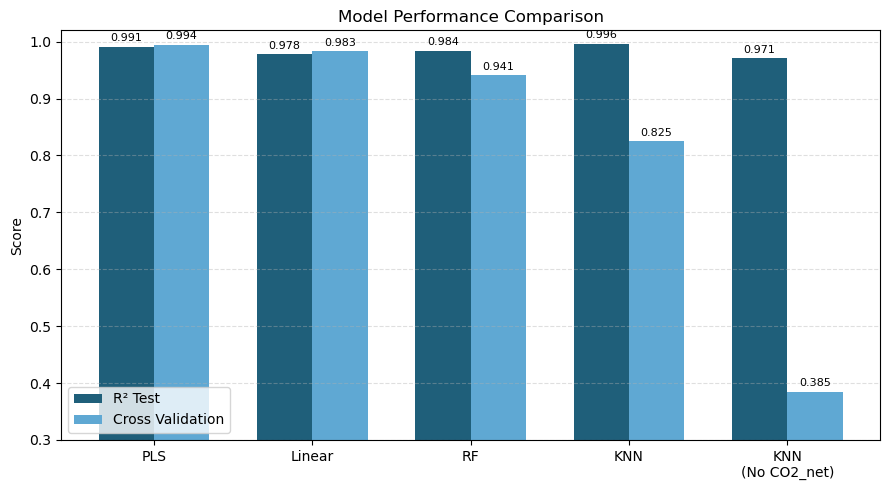